## Tarea 1: Repaso básicos de ML — Soluciones

In [1]:
# paquete central de PyTorch; contiene tensores y las operaciones sobre ellos.
import torch
# módulos y capas de red (e.g., Linear, ReLU, CrossEntropyLoss).
import torch.nn as nn

class LinearRegression(nn.Module):
    """Modelo de regresión lineal implementado desde cero en PyTorch"""
    def __init__(self, num_inputs, lr, sigma=0.01):
        super(LinearRegression, self).__init__()
        # Guardamos los hiperparámetros “a mano”, lo que le pasamos se asigna a la instancia en particular
        self.num_inputs = num_inputs
        self.lr = lr
        self.sigma = sigma
        # Parámetros del modelo: pesos y sesgo
        # nn.Parameter indica a PyTorch que debe calcular gradientes sobre este tensor
        self.w = nn.Parameter(
            torch.normal(0.0, sigma, size=(num_inputs, 1))
        )
        self.b = nn.Parameter(
            torch.zeros(1)
        )
    
    def forward(self, X):
        """ Calcula la estimación y_hat dados los paramétros actuales y X"""
        return torch.matmul(X, self.w) + self.b
    
    def loss(self, y_hat, y):
        """Calcula la pérdida de regresión lineal
        y devuelve el valor medio sobre el minibatch.
        """
        # 1) Error al cuadrado, escalado por 1/2
        l = (y_hat - y) ** 2 / 2
        # 2) Promedio sobre todas las muestras
        return l.mean()
    
    def configure_optimizers(self):
        """
        Crea y devuelve el optimizador SGD configurado con nuestros parámetros.
        """
        # Pasamos los parámetros w y b al optimizador y la lr
        return SGD([self.w, self.b], self.lr)
    
class SGD:
    """Descenso de gradiente estocástico por minibatches."""
    def __init__(self, params, lr):
        # params: iterable de nn.Parameter
        self.params = list(params)
        self.lr = lr

    def step(self):
        """Actualiza cada parámetro: θ ← θ − lr * ∇θ."""
        for p in self.params:
            # p.grad es el gradiente calculado en backward()
            p.data -= self.lr * p.grad

    def zero_grad(self):
        """Pone a cero todos los gradientes para la siguiente iteración."""
        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()

from torch.utils.data import TensorDataset, DataLoader, random_split
import matplotlib.pyplot as plt

# 1) Creamos datos sinteticos para probar nuestra infra: 
def synthetic_regression_data(w, b, num_samples=1000):
    """Genera X ~ N(0,1) y y = Xw + b + ruido."""
    num_inputs = w.shape[0]
    X = torch.randn(num_samples, num_inputs)
    y = X @ w.reshape(-1, 1) + b
    y += torch.randn_like(y) * 0.01  # agrega ruido a nuestros datos 
    return X, y

# 2) Preparamos datos y dataloaders
true_w = torch.tensor([2.0, -3.4])
true_b = 4.2
X, y = synthetic_regression_data(true_w, true_b)


# 3) Crear TensorDataset y dividir en train/validation
dataset = TensorDataset(X, y)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

Preguntas de programción: 

1. Regresión lineal desde cero

In [2]:
# --- Comparación: nn.Linear(2,1) vs. LinearRegression(num_inputs=2) ---
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(0)

# 1) Datos sintéticos con 2 features
true_w = torch.tensor([2.0, -3.4])
true_b = torch.tensor(4.2)
X, y = synthetic_regression_data(true_w, true_b, num_samples=200)

dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

# 2a) Modelo PyTorch: nn.Linear(2,1)
model_torch = nn.Linear(2, 1)
crit = nn.MSELoss()
opt_torch = optim.SGD(model_torch.parameters(), lr=0.03)

for epoch in range(100):
    for xb, yb in loader:
        opt_torch.zero_grad()
        y_hat = model_torch(xb)
        loss = crit(y_hat, yb)
        loss.backward()
        opt_torch.step()

w_torch = model_torch.weight.detach().reshape(-1)  # (2,)
b_torch = model_torch.bias.detach().item()

# 2b) Tu modelo: LinearRegression(num_inputs=2)
model_manual = LinearRegression(num_inputs=2, lr=0.03)
opt_manual = model_manual.configure_optimizers()

for epoch in range(100):
    for xb, yb in loader:
        y_hat2 = model_manual(xb)
        loss2 = model_manual.loss(y_hat2, yb)
        opt_manual.zero_grad()
        loss2.backward()
        opt_manual.step()

w_manual = model_manual.w.detach().reshape(-1)     # (2,)
b_manual = model_manual.b.detach().item()

# 3) Evaluación y comparación
with torch.no_grad():
    mse_torch = crit(model_torch(X), y).item()
    mse_manual = model_manual.loss(model_manual(X), y).item()

print("=== Resultados ===")
print(f"Parámetros verdaderos:  w* = {true_w.tolist()},  b* = {true_b.item():.4f}\n")

print("[nn.Linear(2,1)]")
print(f"w_pytorch = {w_torch.tolist()}")
print(f"b_pytorch = {b_torch:.4f}")
print(f"MSE total = {mse_torch:.6f}\n")

print("[LinearRegression(num_inputs=2)]")
print(f"w_manual  = {w_manual.tolist()}")
print(f"b_manual  = {b_manual:.4f}")
print(f"MSE total = {mse_manual:.6f}\n")

# Diferencias elemento a elemento
dw = (w_manual - w_torch).abs()
db = abs(b_manual - b_torch)
print("Diferencias absolutas |manual - torch|")
print(f"|Δw| = {dw.tolist()}")
print(f"|Δb| = {db:.6f}")


=== Resultados ===
Parámetros verdaderos:  w* = [2.0, -3.4000000953674316],  b* = 4.2000

[nn.Linear(2,1)]
w_pytorch = [1.9999526739120483, -3.40006947517395]
b_pytorch = 4.2008
MSE total = 0.000117

[LinearRegression(num_inputs=2)]
w_manual  = [1.9994795322418213, -3.4001617431640625]
b_manual  = 4.2008
MSE total = 0.000058

Diferencias absolutas |manual - torch|
|Δw| = [0.0004731416702270508, 9.226799011230469e-05]
|Δb| = 0.000058


2. Batch vs. Minibatch

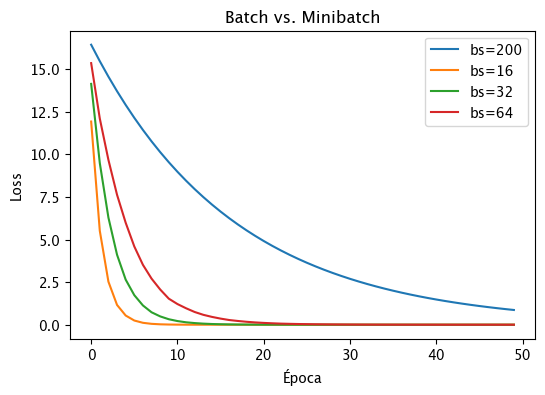

In [3]:
import matplotlib.pyplot as plt

def train_bs(bs):
    model = LinearRegression(num_inputs=2, lr=0.03)
    opt = model.configure_optimizers()
    loader = DataLoader(TensorDataset(X,y), batch_size=bs, shuffle=True)
    losses = []
    for epoch in range(50):
        total, count = 0.0, 0
        for xb, yb in loader:
            loss = model.loss(model(xb), yb)
            opt.zero_grad()
            loss.backward()
            opt.step()
            total += loss.item() * yb.size(0)
            count += yb.size(0)
        losses.append(total/count)
    return losses

plt.figure(figsize=(6,4))
for bs in [len(X), 16, 32, 64]:
    losses = train_bs(bs)
    plt.plot(losses, label=f"bs={bs}")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Batch vs. Minibatch")
plt.legend()
plt.show()


3. Closed-form vs. GD

In [4]:
# 3a) Closed-form usando lstsq
X_aug = torch.cat([torch.ones(X.size(0),1), X], dim=1)  # [n,3]
θ, *_ = torch.linalg.lstsq(X_aug, y)                     # [3,1]
print("Closed-form w,b:", θ.flatten().tolist())

# 3b) GD con tu LinearRegression (full batch)
model_gd = LinearRegression(num_inputs=2, lr=0.1)
opt_gd = model_gd.configure_optimizers()
loader_full = DataLoader(TensorDataset(X,y), batch_size=len(X), shuffle=False)
for epoch in range(200):
    for xb, yb in loader_full:
        loss = model_gd.loss(model_gd(xb), yb)
        opt_gd.zero_grad()
        loss.backward()
        opt_gd.step()
print("GD w,b:", model_gd.w.detach().numpy().flatten().tolist(), model_gd.b.item())


Closed-form w,b: [4.2007269859313965, 1.9997224807739258, -3.4002299308776855]
GD w,b: [1.9997212886810303, -3.4002292156219482] 4.2007293701171875


4. Decay de la learning rate

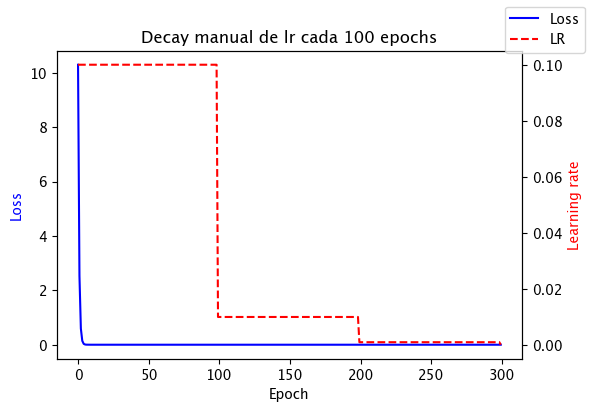

In [5]:
# Notar: tu SGD no soporta scheduler, haremos decay manual
initial_lr = 0.1
model = LinearRegression(num_inputs=2, lr=initial_lr)
opt = model.configure_optimizers()
losses, lrs = [], []

for epoch in range(1, 301):
    # cada 100 epochs bajamos lr ×0.1
    if epoch % 100 == 0:
        opt.lr *= 0.1
    total, count = 0.0, 0
    for xb, yb in DataLoader(TensorDataset(X,y), batch_size=32, shuffle=True):
        loss = model.loss(model(xb), yb)
        opt.zero_grad()
        loss.backward()
        opt.step()
        total += loss.item() * yb.size(0)
        count += yb.size(0)
    losses.append(total/count)
    lrs.append(opt.lr)

import matplotlib.pyplot as plt
fig, ax1 = plt.subplots(figsize=(6,4))
ax1.plot(losses, 'b-', label='Loss')
ax1.set_ylabel('Loss', color='b')
ax2 = ax1.twinx()
ax2.plot(lrs, 'r--', label='LR')
ax2.set_ylabel('Learning rate', color='r')
ax1.set_xlabel('Epoch')
fig.legend(loc='upper right')
plt.title('Decay manual de lr cada 100 epochs')
plt.show()
